# CosineAnnealingWarmRestartsDecay Visualization

This notebook visualizes the custom learning rate scheduler that combines:
- **Cosine Annealing**: Smooth LR transitions within each cycle
- **Warm Restarts**: Multiple training cycles for better exploration
- **LR Decay**: Reduces max LR after each restart for stability in later phases
- **Smooth Ending**: Distributes remainder epochs to later cycles so training ends at eta_min

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Set style for better visualization
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
class CosineAnnealingWarmRestartsDecay:
    """
    Cosine annealing scheduler with warm restarts and optional LR decay.

    Similar to PyTorch's CosineAnnealingWarmRestarts but with decay factor
    that reduces the max LR after each restart. This is useful for progressive
    augmentation where early phases need high LR and later phases benefit from
    more stable, lower LR.

    When total_epochs is provided, the scheduler keeps the same number of cycles
    (total_epochs // T_0) but distributes any remainder epochs across the later
    cycles. This ensures each cycle completes a full smooth cosine curve and
    training ends exactly at eta_min.

    Args:
        optimizer: Wrapped optimizer
        T_0: Number of epochs for the first restart cycle
        T_mult: Factor to increase cycle length after each restart (default: 1)
        eta_min: Minimum learning rate (default: 1e-6)
        decay: Factor to multiply max LR after each restart (default: 1.0, no decay)
               e.g., decay=0.8 means max LR becomes 80% after each restart
        total_epochs: Total number of training epochs (required for smooth ending)

    Example with T_0=12, decay=0.8, base_lr=1e-4, total_epochs=50:
        num_cycles = 50 // 12 = 4, remainder = 50 % 12 = 2
        Cycle lengths: [12, 12, 13, 13] (remainder distributed to later cycles)
        Each cycle completes a full smooth cosine from max_lr to eta_min
    """

    def __init__(
        self,
        optimizer,
        T_0,
        T_mult=1,
        eta_min=1e-6,
        decay=1.0,
        last_epoch=-1,
        total_epochs=None,
    ):
        self.optimizer = optimizer
        self.T_0 = T_0
        self.T_mult = T_mult
        self.eta_min = eta_min
        self.decay = decay
        self.last_epoch = last_epoch
        self.total_epochs = total_epochs

        # Store base learning rates
        self.base_lrs = [group["lr"] for group in optimizer.param_groups]

        # Track current cycle
        self.T_cur = 0  # Current position in cycle
        self.T_i = T_0  # Current cycle length
        self.cycle = 0  # Current cycle number

        # Pre-compute cycle boundaries for smooth ending
        self._cycle_starts = None  # Start epoch for each cycle
        self._cycle_lengths = None  # Length of each cycle
        self._num_cycles = None
        if total_epochs is not None and T_mult == 1:
            self._compute_cycle_boundaries()

    def _compute_cycle_boundaries(self):
        """
        Compute cycle start epochs and lengths to fit total_epochs exactly.
        Distributes remainder epochs to the later cycles.
        """
        num_cycles = self.total_epochs // self.T_0
        if num_cycles == 0:
            num_cycles = 1  # At least one cycle

        remainder = self.total_epochs - (num_cycles * self.T_0)

        # Distribute remainder to later cycles
        # e.g., 50 epochs, T_0=12, num_cycles=4, remainder=2
        # lengths = [12, 12, 13, 13]
        self._cycle_lengths = []
        for i in range(num_cycles):
            length = self.T_0
            # Add 1 to later cycles to distribute remainder
            if i >= num_cycles - remainder:
                length += 1
            self._cycle_lengths.append(length)

        # Compute start epochs for each cycle
        self._cycle_starts = [0]
        for i in range(num_cycles - 1):
            self._cycle_starts.append(self._cycle_starts[-1] + self._cycle_lengths[i])

        self._num_cycles = num_cycles

    def _get_cycle_info(self, epoch):
        """Get cycle number, position within cycle, and cycle length for given epoch."""
        if self._cycle_starts is None:
            # Fallback to original behavior
            if epoch >= self.T_0:
                if self.T_mult == 1:
                    return epoch // self.T_0, epoch % self.T_0, self.T_0
                else:
                    n = int(
                        np.log((epoch / self.T_0 * (self.T_mult - 1) + 1))
                        / np.log(self.T_mult)
                    )
                    T_cur = epoch - self.T_0 * (self.T_mult**n - 1) // (self.T_mult - 1)
                    T_i = self.T_0 * self.T_mult**n
                    return n, T_cur, T_i
            else:
                return 0, epoch, self.T_0

        # Find which cycle this epoch belongs to
        for i in range(self._num_cycles - 1, -1, -1):
            if epoch >= self._cycle_starts[i]:
                T_cur = epoch - self._cycle_starts[i]
                T_i = self._cycle_lengths[i]
                return i, T_cur, T_i

        return 0, epoch, self._cycle_lengths[0]

    def get_lr(self):
        """Calculate learning rate for current epoch"""
        # Calculate decay factor based on cycle number
        decay_factor = self.decay**self.cycle

        # Cosine annealing within current cycle
        # Use (T_i - 1) as denominator so that the last epoch (T_cur = T_i - 1)
        # reaches exactly eta_min (cos(π) = -1)
        # This ensures smooth ending at minimum LR
        T_denom = max(self.T_i - 1, 1)  # Avoid division by zero for single-epoch cycles
        lrs = [
            self.eta_min
            + (base_lr * decay_factor - self.eta_min)
            * 0.5
            * (1 + np.cos(np.pi * self.T_cur / T_denom))
            for base_lr in self.base_lrs
        ]
        return lrs

    def step(self, epoch=None):
        """Update learning rate"""
        if epoch is None:
            epoch = self.last_epoch + 1
        self.last_epoch = epoch

        # Get cycle info (handles both old and new behavior)
        self.cycle, self.T_cur, self.T_i = self._get_cycle_info(epoch)

        lrs = self.get_lr()
        for param_group, lr in zip(self.optimizer.param_groups, lrs):
            param_group["lr"] = lr

## Helper: Collect LR schedule

In [3]:
def collect_lrs(base_lr, T_0, decay, eta_min, total_epochs, use_total_epochs=True):
    """Simulate scheduler and collect LRs for each epoch."""
    # Create a dummy model and optimizer
    model = nn.Linear(1, 1)
    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)
    
    # Create scheduler
    scheduler = CosineAnnealingWarmRestartsDecay(
        optimizer, 
        T_0=T_0, 
        decay=decay, 
        eta_min=eta_min, 
        total_epochs=total_epochs if use_total_epochs else None
    )
    
    lrs = []
    for epoch in range(total_epochs):
        scheduler.step(epoch)
        lrs.append(optimizer.param_groups[0]['lr'])
    
    return lrs, scheduler

## 1. The Problem: LR Spike at End of Training

When `epochs` doesn't divide evenly by `T_0`, the scheduler starts a new cycle at the end.

epochs=50, T_0=12
Problem: 50 = 12*4 + 2 (2 epochs remainder)
Without fix: cycles [12, 12, 12, 12] = 48 epochs, then NEW CYCLE at 48!


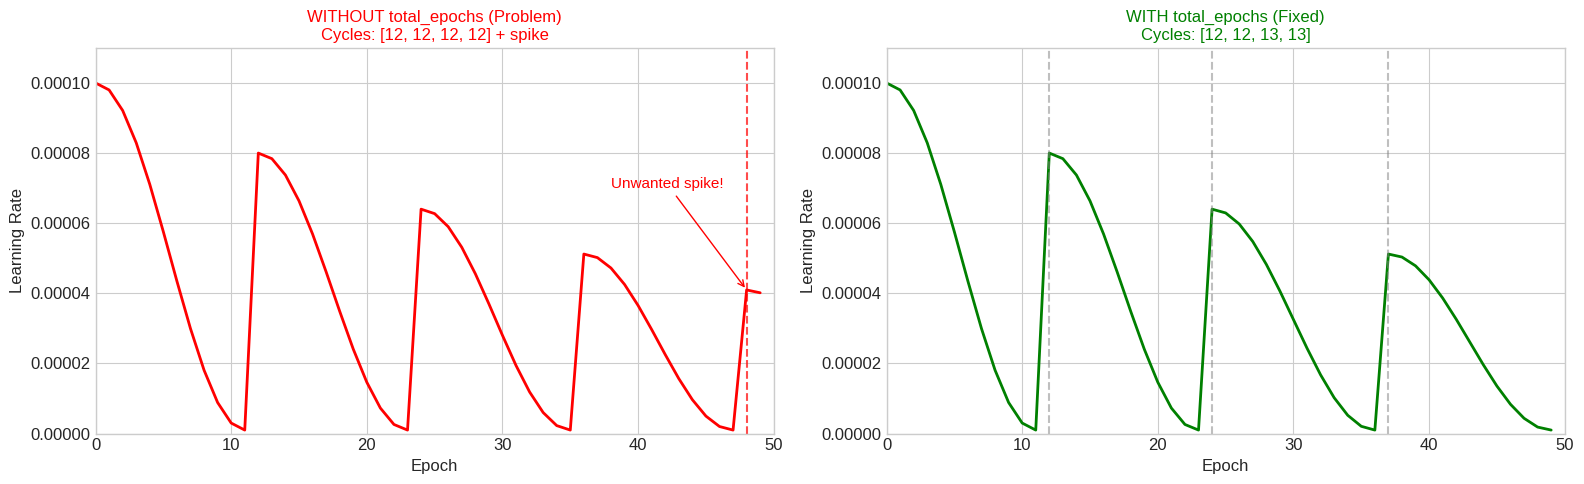


Old: LR at epoch 47 = 1.00e-06, epoch 48 = 4.10e-05 (SPIKE!)
New: LR at epoch 48 = 1.86e-06, epoch 49 = 1.00e-06 (ends at eta_min)


In [4]:
# Parameters
epochs = 50
base_lr = 1e-4
T_0 = epochs // 4  # = 12
eta_min = 1e-6

print(f"epochs={epochs}, T_0={T_0}")
print(f"Problem: 50 = 12*4 + 2 (2 epochs remainder)")
print(f"Without fix: cycles [12, 12, 12, 12] = 48 epochs, then NEW CYCLE at 48!")

# Old behavior (without total_epochs)
lrs_old, _ = collect_lrs(base_lr, T_0, decay=0.8, eta_min=eta_min, total_epochs=epochs, use_total_epochs=False)

# New behavior (with total_epochs - distributed remainder)
lrs_new, scheduler_new = collect_lrs(base_lr, T_0, decay=0.8, eta_min=eta_min, total_epochs=epochs, use_total_epochs=True)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Old behavior
axes[0].plot(range(epochs), lrs_old, 'r-', linewidth=2)
axes[0].axvline(x=48, color='red', linestyle='--', alpha=0.7)
axes[0].annotate('Unwanted spike!', xy=(48, lrs_old[48]), xytext=(38, base_lr*0.7),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Learning Rate', fontsize=12)
axes[0].set_title('WITHOUT total_epochs (Problem)\nCycles: [12, 12, 12, 12] + spike', fontsize=12, color='red')
axes[0].set_xlim(0, epochs)
axes[0].set_ylim(0, base_lr * 1.1)

# New behavior
axes[1].plot(range(epochs), lrs_new, 'g-', linewidth=2)
# Mark cycle boundaries
for start in scheduler_new._cycle_starts[1:]:
    axes[1].axvline(x=start, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Learning Rate', fontsize=12)
axes[1].set_title(f'WITH total_epochs (Fixed)\nCycles: {scheduler_new._cycle_lengths}', fontsize=12, color='green')
axes[1].set_xlim(0, epochs)
axes[1].set_ylim(0, base_lr * 1.1)

plt.tight_layout()
plt.show()

print(f"\nOld: LR at epoch 47 = {lrs_old[47]:.2e}, epoch 48 = {lrs_old[48]:.2e} (SPIKE!)")
print(f"New: LR at epoch 48 = {lrs_new[48]:.2e}, epoch 49 = {lrs_new[49]:.2e} (ends at eta_min)")

## 2. How It Works: Distribute Remainder to Later Cycles

Instead of starting a new partial cycle, we make later cycles slightly longer.

In [5]:
print(f"T_0 = {T_0}, total_epochs = {epochs}")
print(f"\nCalculation:")
print(f"  num_cycles = {epochs} // {T_0} = {epochs // T_0}")
print(f"  remainder = {epochs} - ({epochs // T_0} * {T_0}) = {epochs - (epochs // T_0) * T_0}")
print(f"\nDistribute remainder to LATER cycles:")

_, scheduler = collect_lrs(base_lr, T_0, decay=0.8, eta_min=eta_min, total_epochs=epochs)
print(f"  Cycle lengths: {scheduler._cycle_lengths}")
print(f"  Cycle starts:  {scheduler._cycle_starts}")
print(f"  Total: {sum(scheduler._cycle_lengths)} epochs")

print(f"\nEach cycle is still a COMPLETE smooth cosine curve!")
print(f"Cycle 0: epochs 0-11  (12 epochs)")
print(f"Cycle 1: epochs 12-23 (12 epochs)")
print(f"Cycle 2: epochs 24-36 (13 epochs) <- +1")
print(f"Cycle 3: epochs 37-49 (13 epochs) <- +1")

T_0 = 12, total_epochs = 50

Calculation:
  num_cycles = 50 // 12 = 4
  remainder = 50 - (4 * 12) = 2

Distribute remainder to LATER cycles:
  Cycle lengths: [12, 12, 13, 13]
  Cycle starts:  [0, 12, 24, 37]
  Total: 50 epochs

Each cycle is still a COMPLETE smooth cosine curve!
Cycle 0: epochs 0-11  (12 epochs)
Cycle 1: epochs 12-23 (12 epochs)
Cycle 2: epochs 24-36 (13 epochs) <- +1
Cycle 3: epochs 37-49 (13 epochs) <- +1


## 3. Decay Comparison: decay=1.0 vs decay=0.8

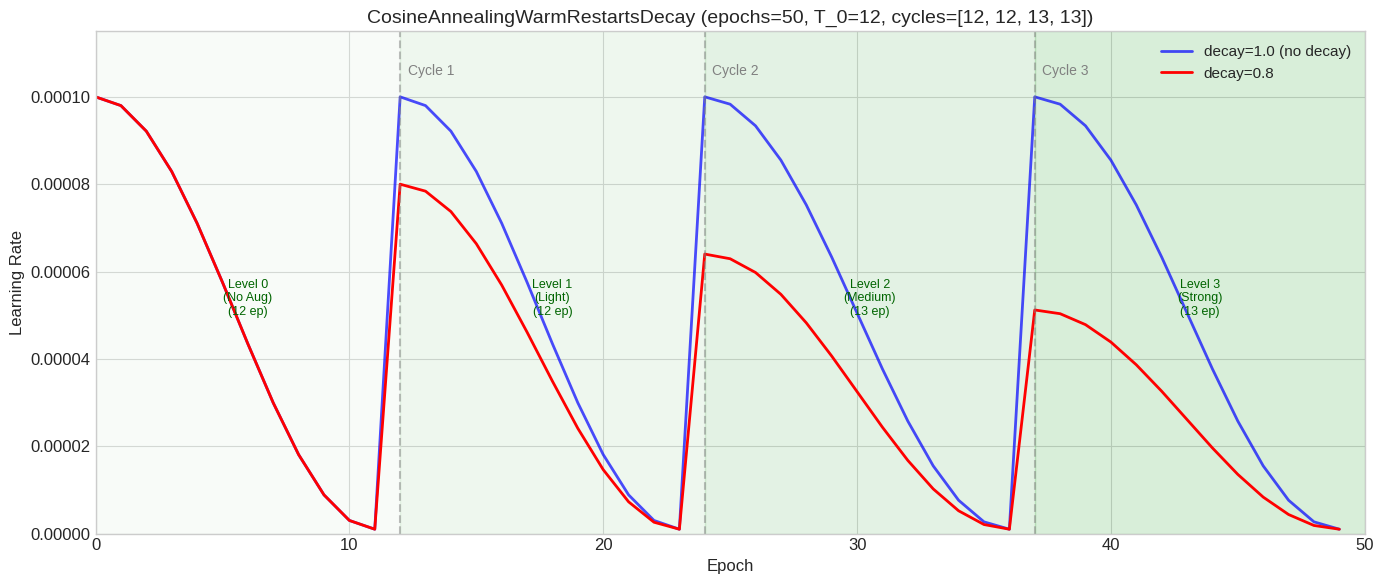

In [6]:
lrs_no_decay, _ = collect_lrs(base_lr, T_0, decay=1.0, eta_min=eta_min, total_epochs=epochs)
lrs_decay, scheduler_decay = collect_lrs(base_lr, T_0, decay=0.8, eta_min=eta_min, total_epochs=epochs)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(range(epochs), lrs_no_decay, 'b-', linewidth=2, label='decay=1.0 (no decay)', alpha=0.7)
ax.plot(range(epochs), lrs_decay, 'r-', linewidth=2, label='decay=0.8')

# Add cycle boundaries and annotations
cycle_starts = scheduler_decay._cycle_starts
cycle_lengths = scheduler_decay._cycle_lengths
aug_colors = ['#e8f5e9', '#c8e6c9', '#a5d6a7', '#81c784']
aug_labels = ['Level 0\n(No Aug)', 'Level 1\n(Light)', 'Level 2\n(Medium)', 'Level 3\n(Strong)']

for i, (start, length) in enumerate(zip(cycle_starts, cycle_lengths)):
    end = start + length
    ax.axvspan(start, end, alpha=0.3, color=aug_colors[i])
    ax.text(start + length/2, base_lr * 0.5, f'{aug_labels[i]}\n({length} ep)', ha='center', fontsize=9, color='darkgreen')
    if i > 0:
        ax.axvline(x=start, color='gray', linestyle='--', alpha=0.5)
        ax.text(start + 0.3, base_lr * 1.05, f'Cycle {i}', fontsize=10, color='gray')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title(f'CosineAnnealingWarmRestartsDecay (epochs={epochs}, T_0={T_0}, cycles={cycle_lengths})', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(0, epochs)
ax.set_ylim(0, base_lr * 1.15)

plt.tight_layout()
plt.show()

## 4. Different Decay Values

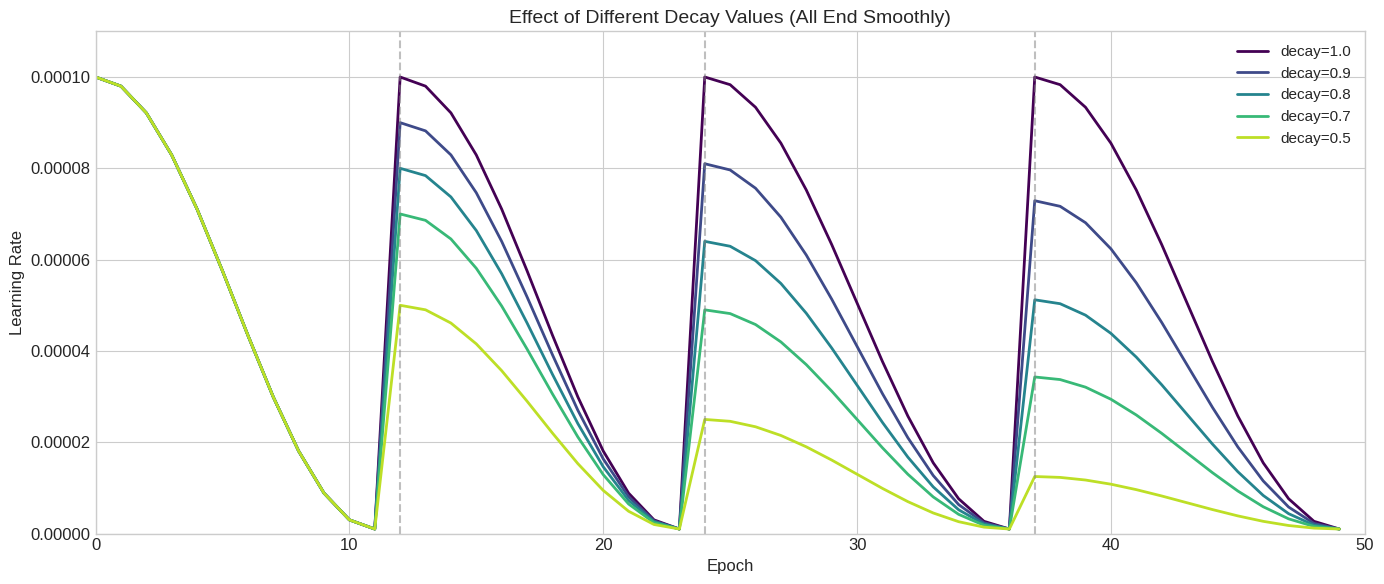

In [7]:
decay_values = [1.0, 0.9, 0.8, 0.7, 0.5]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(decay_values)))

fig, ax = plt.subplots(figsize=(14, 6))

for decay, color in zip(decay_values, colors):
    lrs, scheduler = collect_lrs(base_lr, T_0, decay=decay, eta_min=eta_min, total_epochs=epochs)
    ax.plot(range(epochs), lrs, color=color, linewidth=2, label=f'decay={decay}')

# Add cycle boundaries
for start in scheduler._cycle_starts[1:]:
    ax.axvline(x=start, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Effect of Different Decay Values (All End Smoothly)', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(0, epochs)
ax.set_ylim(0, base_lr * 1.1)

plt.tight_layout()
plt.show()

## 5. Works with Any Epoch Count

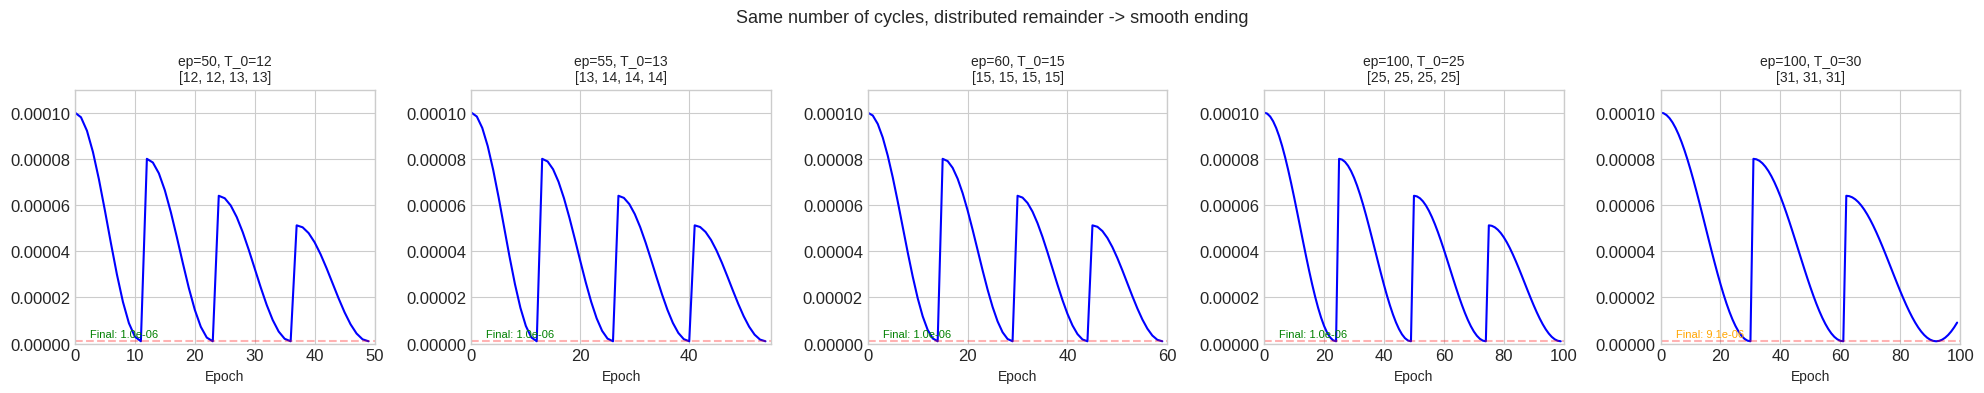

In [8]:
# Test with different epoch counts - all end smoothly!
test_cases = [
    (50, 12),   # 50 = 12*4 + 2 -> [12,12,13,13]
    (55, 13),   # 55 = 13*4 + 3 -> [13,13,14,14]
    (60, 15),   # 60 = 15*4 + 0 -> [15,15,15,15] perfect fit
    (100, 25),  # 100 = 25*4 + 0 -> [25,25,25,25] perfect fit
    (100, 30),  # 100 = 30*3 + 10 -> distribute to cycles
]

fig, axes = plt.subplots(1, len(test_cases), figsize=(20, 4))

for ax, (ep, t0) in zip(axes, test_cases):
    lrs, scheduler = collect_lrs(base_lr, t0, decay=0.8, eta_min=eta_min, total_epochs=ep)
    
    ax.plot(range(ep), lrs, 'b-', linewidth=1.5)
    ax.set_title(f'ep={ep}, T_0={t0}\n{scheduler._cycle_lengths}', fontsize=10)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_xlim(0, ep)
    ax.set_ylim(0, base_lr * 1.1)
    
    # Verify last LR is near eta_min
    last_lr = lrs[-1]
    ax.axhline(y=eta_min, color='r', linestyle='--', alpha=0.3)
    color = 'green' if abs(last_lr - eta_min) < 1e-7 else 'orange'
    ax.text(ep * 0.05, eta_min * 3, f'Final: {last_lr:.1e}', fontsize=8, color=color)

plt.suptitle('Same number of cycles, distributed remainder -> smooth ending', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Max LR Per Cycle

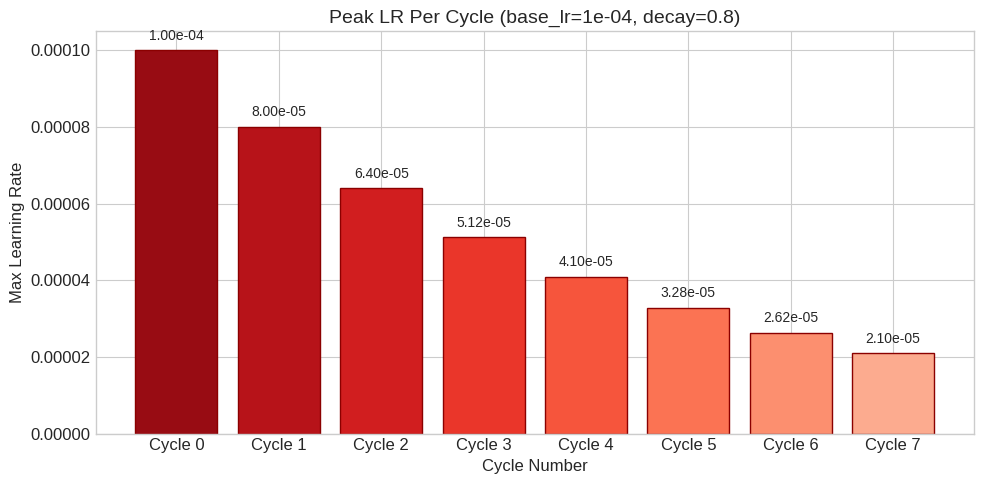

Max LR reduction per cycle:
  Cycle 0: 1.00e-04 (100.0% of base LR)
  Cycle 1: 8.00e-05 (80.0% of base LR)
  Cycle 2: 6.40e-05 (64.0% of base LR)
  Cycle 3: 5.12e-05 (51.2% of base LR)
  Cycle 4: 4.10e-05 (41.0% of base LR)
  Cycle 5: 3.28e-05 (32.8% of base LR)
  Cycle 6: 2.62e-05 (26.2% of base LR)
  Cycle 7: 2.10e-05 (21.0% of base LR)


In [9]:
decay = 0.8
num_cycles_show = 8

max_lrs = [base_lr * (decay ** i) for i in range(num_cycles_show)]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(range(num_cycles_show), max_lrs, color=plt.cm.Reds(np.linspace(0.9, 0.3, num_cycles_show)), edgecolor='darkred')

for i, (bar, lr) in enumerate(zip(bars, max_lrs)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + base_lr*0.02, 
            f'{lr:.2e}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Cycle Number', fontsize=12)
ax.set_ylabel('Max Learning Rate', fontsize=12)
ax.set_title(f'Peak LR Per Cycle (base_lr={base_lr:.0e}, decay={decay})', fontsize=14)
ax.set_xticks(range(num_cycles_show))
ax.set_xticklabels([f'Cycle {i}' for i in range(num_cycles_show)])

plt.tight_layout()
plt.show()

print("Max LR reduction per cycle:")
for i, lr in enumerate(max_lrs):
    pct = (lr / base_lr) * 100
    print(f"  Cycle {i}: {lr:.2e} ({pct:.1f}% of base LR)")

## 7. Interactive: Custom Parameters

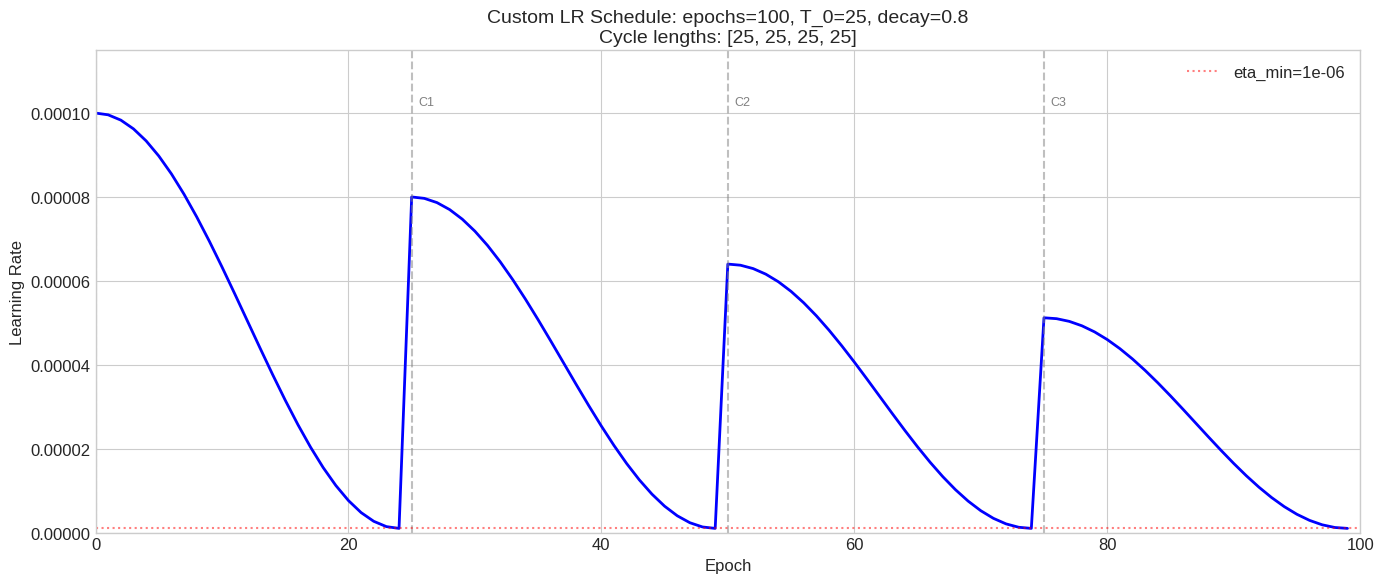

Final LR: 1.00e-06
Ends at eta_min: True


In [10]:
# Customize these parameters to see different LR schedules
EPOCHS = 100
BASE_LR = 1e-4
T_0 = 25        # Epochs per cycle
DECAY = 0.8     # LR decay after each restart
ETA_MIN = 1e-6  # Minimum learning rate

lrs, scheduler = collect_lrs(BASE_LR, T_0, DECAY, ETA_MIN, EPOCHS)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(range(EPOCHS), lrs, 'b-', linewidth=2)

# Mark cycle boundaries
if scheduler._cycle_starts:
    for i, start in enumerate(scheduler._cycle_starts):
        ax.axvline(x=start, color='gray', linestyle='--', alpha=0.5)
        if i > 0:
            ax.text(start + 0.5, BASE_LR * 1.02, f'C{i}', fontsize=9, color='gray')

ax.axhline(y=ETA_MIN, color='r', linestyle=':', alpha=0.5, label=f'eta_min={ETA_MIN:.0e}')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title(f'Custom LR Schedule: epochs={EPOCHS}, T_0={T_0}, decay={DECAY}\nCycle lengths: {scheduler._cycle_lengths}', fontsize=14)
ax.legend()
ax.set_xlim(0, EPOCHS)
ax.set_ylim(0, BASE_LR * 1.15)

plt.tight_layout()
plt.show()

print(f"Final LR: {lrs[-1]:.2e}")
print(f"Ends at eta_min: {abs(lrs[-1] - ETA_MIN) < 1e-10}")

## Summary

**CosineAnnealingWarmRestartsDecay** features:

1. **Cosine Annealing**: Smooth LR reduction within each cycle

2. **Warm Restarts**: Multiple exploration phases

3. **Decay Factor**: Reduces max LR after each restart

4. **Smooth Ending**: When `total_epochs` is provided:
   - Keeps same number of cycles: `num_cycles = total_epochs // T_0`
   - Distributes remainder to later cycles
   - Example: 50 epochs, T_0=12 -> cycles [12, 12, 13, 13] instead of [12, 12, 12, 12] + spike
   - Each cycle is still a complete smooth cosine curve
   - Training ends exactly at eta_min

This ensures stable convergence without unexpected LR spikes at the end of training.